In [1]:
import duckdb
import pandas as pd
import openpyxl

In [3]:
temp_df = pd.read_excel('../cleaned_data/online_retail_II_cleaned.xlsx')
duckdb.sql("""
SELECT *
FROM temp_df
LIMIT 1
""").df()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom


In [4]:
import numpy as np

# 1. The Systems Thinking SQL: Clean and Aggregate in one go
# Pointing DuckDB directly at your loaded 'temp_df'
rfm_query = """
WITH cleaned_data AS (
    SELECT 
        "Customer ID" AS customer_id,
        Invoice AS invoice,
        CAST(InvoiceDate AS TIMESTAMP) AS invoice_date,
        (Quantity * Price) AS total_sum
    FROM temp_df
    WHERE "Customer ID" IS NOT NULL 
      AND Quantity > 0 
      AND Price > 0
      AND CAST(Invoice AS VARCHAR) NOT LIKE 'C%' -- Drops cancellations
)

SELECT
    customer_id,
    -- Recency: Days between customer's last order and the very last day in the dataset
    date_diff('day', MAX(invoice_date), (SELECT MAX(invoice_date) FROM cleaned_data)) AS recency,
    -- Frequency: Count of unique invoices (trips to the store)
    COUNT(DISTINCT invoice) AS frequency,
    -- Monetary: Total money spent
    SUM(total_sum) AS monetary
FROM cleaned_data
GROUP BY customer_id
"""
# Execute the query and store as a Pandas DataFrame for ML
rfm_df = duckdb.sql(rfm_query).df()

print("--- Step 1: Raw RFM Table ---")
print(rfm_df.head())
print(f"Total Unique Customers: {len(rfm_df)}")


--- Step 1: Raw RFM Table ---
   customer_id  recency  frequency  monetary
0      15426.0        4          5   1168.00
1      16143.0        4          7   2485.89
2      13652.0        3          3   1475.77
3      16161.0        3         25   7256.24
4      14748.0        3          7   1736.57
Total Unique Customers: 4312


In [5]:
# ---------------------------------------------------------
# Phase 2: Machine Learning Preprocessing (Log Transformation)
# ---------------------------------------------------------
# Why? K-Means clustering uses 'Euclidean Distance' (straight lines). 
# If Monetary ranges from $10 to $100,000, it breaks the math. 
# Log transformation squashes massive outliers into a neat, normal distribution.

# We use np.log1p (which does log(x + 1)) to safely handle any potential zeros
rfm_log_df = rfm_df.copy()
rfm_log_df['recency_log'] = np.log1p(rfm_df['recency'])
rfm_log_df['frequency_log'] = np.log1p(rfm_df['frequency'])
rfm_log_df['monetary_log'] = np.log1p(rfm_df['monetary'])

print("\n--- Step 2: Log Transformed Data (Ready for Scaling) ---")
print(rfm_log_df[['customer_id', 'recency_log', 'frequency_log', 'monetary_log']].head())


--- Step 2: Log Transformed Data (Ready for Scaling) ---
   customer_id  recency_log  frequency_log  monetary_log
0      15426.0     1.609438       1.791759      7.063904
1      16143.0     1.609438       2.079442      7.818788
2      13652.0     1.386294       1.386294      7.297613
3      16161.0     1.386294       3.258097      8.889755
4      14748.0     1.386294       2.079442      7.460243


Running simulations to find the optimal K...


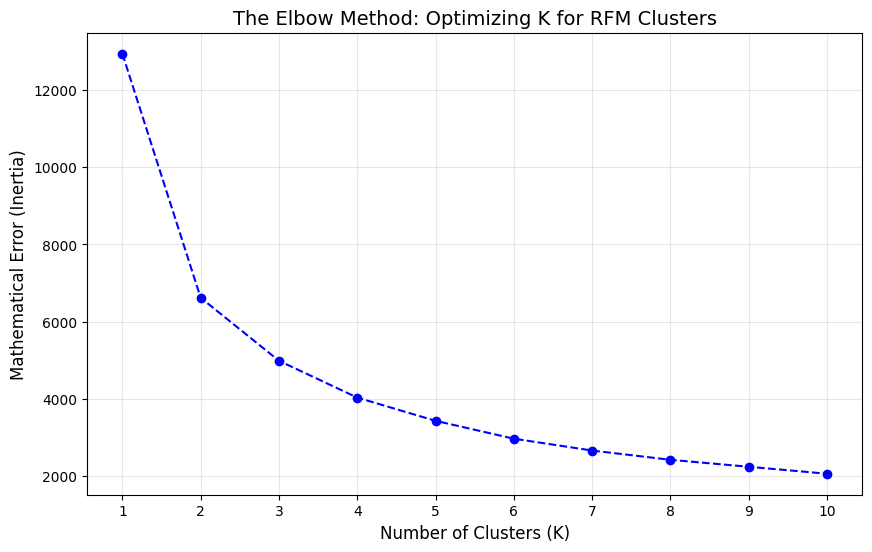

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Isolate the features we want to feed the model
features = ['recency_log', 'frequency_log', 'monetary_log']
X = rfm_log_df[features]

# 2. Scale the data (Standardization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. The Elbow Method (Finding the Sweet Spot)
print("Running simulations to find the optimal K...")
inertia = []
k_range = range(1, 11)

for k in k_range:
    # random_state ensures reproducibility (everyone gets the same result)
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    # Inertia is the mathematical measurement of 'Error' (Euclidean distance)
    inertia.append(kmeans.inertia_)

# 4. Plot the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o', linestyle='--', color='b')
plt.title('The Elbow Method: Optimizing K for RFM Clusters', fontsize=14)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Mathematical Error (Inertia)', fontsize=12)
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
# 1. Train the final model with our chosen K (Adjust to 3 if your elbow is sharper at 3)
OPTIMAL_K = 4 
final_model = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
cluster_labels = final_model.fit_predict(X_scaled)

# 2. The 'Systems Thinking' Merge: 
# Attach the AI's math labels back to the ORIGINAL human-readable business data
rfm_df['Cluster'] = cluster_labels

# 3. Calculate the Business Value of each cluster
cluster_summary = rfm_df.groupby('Cluster').agg({
    'recency': 'mean',
    'frequency': 'mean',
    'monetary': ['mean', 'count']
}).round(1)

# Rename columns for presentation
cluster_summary.columns = ['Avg Recency (Days)', 'Avg Frequency (Trips)', 'Avg Spend (£)', 'Total Customers']
cluster_summary = cluster_summary.sort_values(by='Avg Spend (£)', ascending=False)

print("\n--- FINAL BUSINESS SEGMENTATION ---")
print(cluster_summary)


--- FINAL BUSINESS SEGMENTATION ---
         Avg Recency (Days)  Avg Frequency (Trips)  Avg Spend (£)  \
Cluster                                                             
1                      11.4                   14.4         7937.2   
2                      73.1                    4.4         1878.6   
0                      22.3                    2.0          541.6   
3                     184.4                    1.3          320.0   

         Total Customers  
Cluster                   
1                    693  
2                   1267  
0                    897  
3                   1455  


In [8]:
from sklearn.metrics import silhouette_score

# Assuming X_scaled is still in your memory from the previous steps
print("Calculating Silhouette Scores... (This takes a few seconds)")

# Fit K=3
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_3 = kmeans_3.fit_predict(X_scaled)
sil_score_3 = silhouette_score(X_scaled, labels_3)

# Fit K=4
kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_4 = kmeans_4.fit_predict(X_scaled)
sil_score_4 = silhouette_score(X_scaled, labels_4)

print(f"Mathematical Score for K=3: {sil_score_3:.4f}")
print(f"Mathematical Score for K=4: {sil_score_4:.4f}")
print("-" * 30)
if sil_score_4 >= sil_score_3:
    print("Result: K=4 is mathematically better AND provides better business value.")
elif (sil_score_3 - sil_score_4) < 0.05:
    print("Result: K=3 is slightly better mathematically, but K=4's business value likely justifies the tiny math penalty.")
else:
    print("Result: K=3 is significantly better mathematically. Forcing 4 clusters is creating artificial groups.")

Calculating Silhouette Scores... (This takes a few seconds)
Mathematical Score for K=3: 0.3303
Mathematical Score for K=4: 0.3284
------------------------------
Result: K=3 is slightly better mathematically, but K=4's business value likely justifies the tiny math penalty.


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import pandas as pd

# 1. Define our Inputs (X) and our Target (y)
# We use the scaled features we built earlier, and we try to predict their Cluster
X_model = X_scaled 
y_model = rfm_df['Cluster']

# 2. Split the data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X_model, y_model, test_size=0.2, random_state=42)

# 3. Train the Random Forest
print("Training Random Forest Classifier...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 4. Quiz the AI on the 20% of data it has never seen
predictions = rf_model.predict(X_test)

# 5. Print the Report Card
print("\n--- Model Accuracy Report ---")
print(classification_report(y_test, predictions))

# 6. Extract Feature Importance (The "Why")
importances = rf_model.feature_importances_
feature_names = ['Recency', 'Frequency', 'Monetary']
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("\n--- What drives customer behavior? ---")
print(importance_df)

Training Random Forest Classifier...

--- Model Accuracy Report ---
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       177
           1       0.98      0.98      0.98       133
           2       0.98      0.96      0.97       256
           3       0.98      0.99      0.98       297

    accuracy                           0.97       863
   macro avg       0.97      0.97      0.97       863
weighted avg       0.97      0.97      0.97       863


--- What drives customer behavior? ---
     Feature  Importance
0    Recency    0.407906
2   Monetary    0.305493
1  Frequency    0.286601


In [11]:
import joblib

# 1. Save the Models
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(final_model, 'kmeans_model.joblib')
joblib.dump(rf_model, 'rf_model.joblib')

# 2. Save the dataset for the 3D Graph on the dashboard
rfm_df.to_parquet('dashboard_data.parquet')

print("Models and Data successfully exported! Ready for Streamlit.")

Models and Data successfully exported! Ready for Streamlit.
